# 07 - Training FCNN 4-Class (Analisis Tambahan - Facial Landmark)

**Tujuan:** Melatih model FCNN untuk pengenalan emosi 4 kelas menggunakan fitur geometris dari facial landmark (68 titik x 2 koordinat = 136 fitur).

**Kelas Emosi:** neutral, happy, sad, negative

**3 Skenario Imbalance:**
- B1: Tanpa penanganan (baseline)
- B2: Dengan class weights (Cui et al., 2019)
- B3: Dengan class weights + augmentasi

## 1. Setup

In [1]:
import sys
import os
import json
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from training.models import EmotionFCNN
from training.utils import (
    EmotionLandmarkDataset, get_class_weights,
    train_model, full_evaluation,
    plot_training_history, plot_confusion_matrix, plot_per_class_f1
)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


## 2. Config

In [2]:
# Config
DATASET_DIR = PROJECT_ROOT / "data" / "dataset_4class"
DATASET_AUG_DIR = PROJECT_ROOT / "data" / "dataset_4class_augmented"
OUTPUT_DIR = PROJECT_ROOT / "models" / "4class" / "fcnn"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 128
EPOCHS = 100
LR = 0.0001
PATIENCE = 20
NUM_CLASSES = 4

EMOTIONS = ["neutral", "happy", "sad", "negative"]
print(f"Dataset: {DATASET_DIR}")
print(f"Augmented: {DATASET_AUG_DIR}")
print(f"Output: {OUTPUT_DIR}")

Dataset: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_4class
Augmented: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_4class_augmented
Output: /home/bs000716/MOTHER-TANK/TRAIN/models/4class/fcnn


## 3. Load Data

In [3]:
from torch.utils.data import DataLoader
from collections import Counter

def load_dataloaders(dataset_dir, batch_size=128):
    """Load train/val/test dataloaders."""
    train_ds = EmotionLandmarkDataset(
        dataset_dir / "X_train_landmarks.npy",
        dataset_dir / "y_train.npy"
    )
    val_ds = EmotionLandmarkDataset(
        dataset_dir / "X_val_landmarks.npy",
        dataset_dir / "y_val.npy"
    )
    test_ds = EmotionLandmarkDataset(
        dataset_dir / "X_test_landmarks.npy",
        dataset_dir / "y_test.npy"
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    # Print info
    y_train = np.load(dataset_dir / "y_train.npy")
    counts = Counter(y_train.tolist())
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    print(f"Train distribution:")
    for i, emo in enumerate(EMOTIONS):
        print(f"  {emo:>10s}: {counts.get(i, 0)}")

    return train_loader, val_loader, test_loader

# Load original dataset
train_loader, val_loader, test_loader = load_dataloaders(DATASET_DIR, BATCH_SIZE)

Train: 7064 | Val: 1174 | Test: 1656
Train distribution:
     neutral: 5678
       happy: 751
         sad: 490
    negative: 145


## 4. Skenario B1: Baseline (Tanpa Class Weights)

In [4]:
# B1: Baseline - no class weights
model_b1 = EmotionFCNN(input_dim=136, num_classes=NUM_CLASSES).to(device)
criterion_b1 = nn.CrossEntropyLoss()
optimizer_b1 = torch.optim.Adam(model_b1.parameters(), lr=LR)
scheduler_b1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_b1, mode="max", factor=0.5, patience=8, min_lr=1e-7
)

print(f"Model parameters: {sum(p.numel() for p in model_b1.parameters()):,}")
print("Training B1 (baseline)...")
history_b1, best_epoch_b1 = train_model(
    model_b1, train_loader, val_loader, criterion_b1, optimizer_b1, scheduler_b1,
    device, model_type="fcnn", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "fcnn_4c_b1_baseline.pth")
)

Model parameters: 597,380
Training B1 (baseline)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.1670     0.5330     0.9905    0.9284   0.2407   0.000100  (0.9s)


     2      0.9446     0.7273     0.7606    0.9267   0.2405   0.000100  (0.7s)


     3      0.8029     0.7861     0.6531    0.9302   0.3123   0.000100  (0.6s)


     4      0.7242     0.8045     0.5386    0.9319   0.3304   0.000100  (0.7s)


...

    63      0.4563     0.8403     0.3340    0.9353   0.4285   0.000013  (0.6s)


    64      0.4555     0.8383     0.3279    0.9361   0.4362   0.000013  (0.6s)


    65      0.4533     0.8423     0.3267    0.9361   0.4354   0.000013  (0.7s)


    66      0.4458     0.8447     0.3331    0.9327   0.4239   0.000006  (0.6s)


    67      0.4568     0.8396     0.3296    0.9344   0.4299   0.000006  (0.6s)

Early stopping at epoch 67. Best epoch: 47 (val_f1=0.4650)

Best: epoch 47, val_acc=0.9378, val_f1=0.4650
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/4class/fcnn/fcnn_4c_b1_baseline.pth


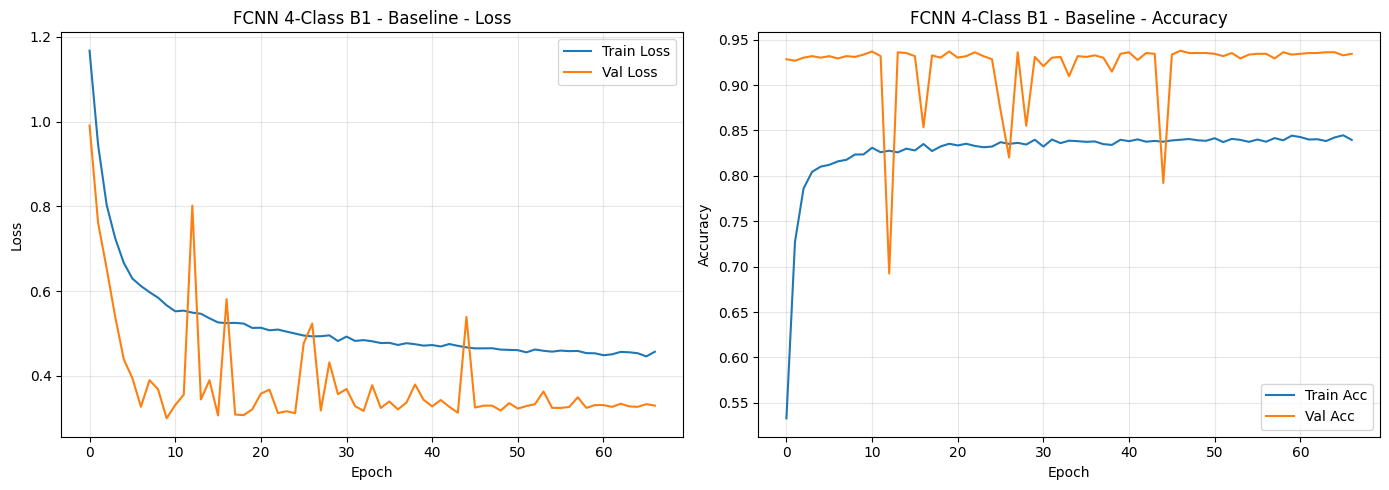

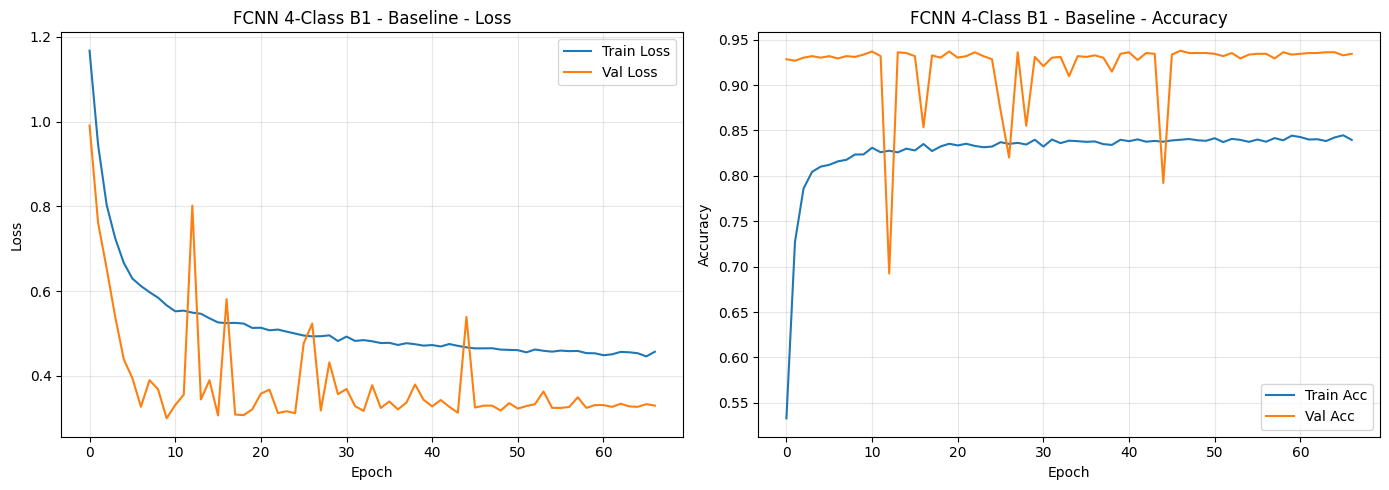

In [5]:
plot_training_history(history_b1, "FCNN 4-Class B1 - Baseline")

EVALUASI B1 - BASELINE


Test Loss: 0.1819
Test Accuracy: 0.9583
Test Macro F1: 0.3301
Test Weighted F1: 0.9430

Classification Report:
              precision    recall  f1-score   support

     neutral       0.96      1.00      0.98      1588
       happy       0.33      0.20      0.25        10
         sad       0.33      0.05      0.09        38
    negative       0.00      0.00      0.00        20

    accuracy                           0.96      1656
   macro avg       0.41      0.31      0.33      1656
weighted avg       0.93      0.96      0.94      1656



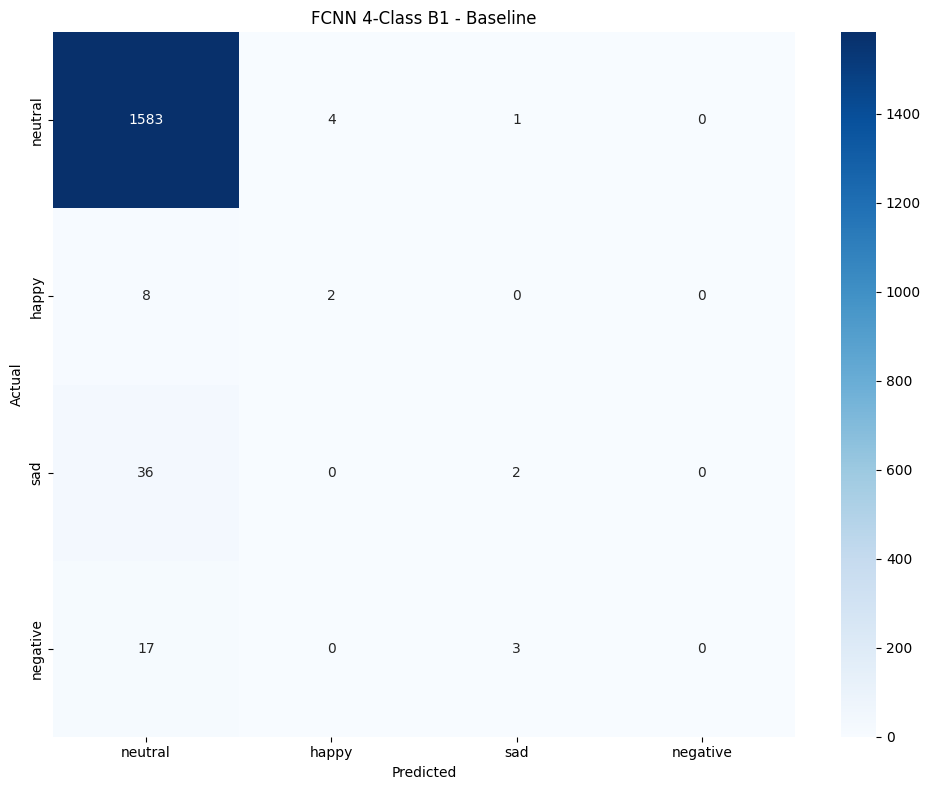

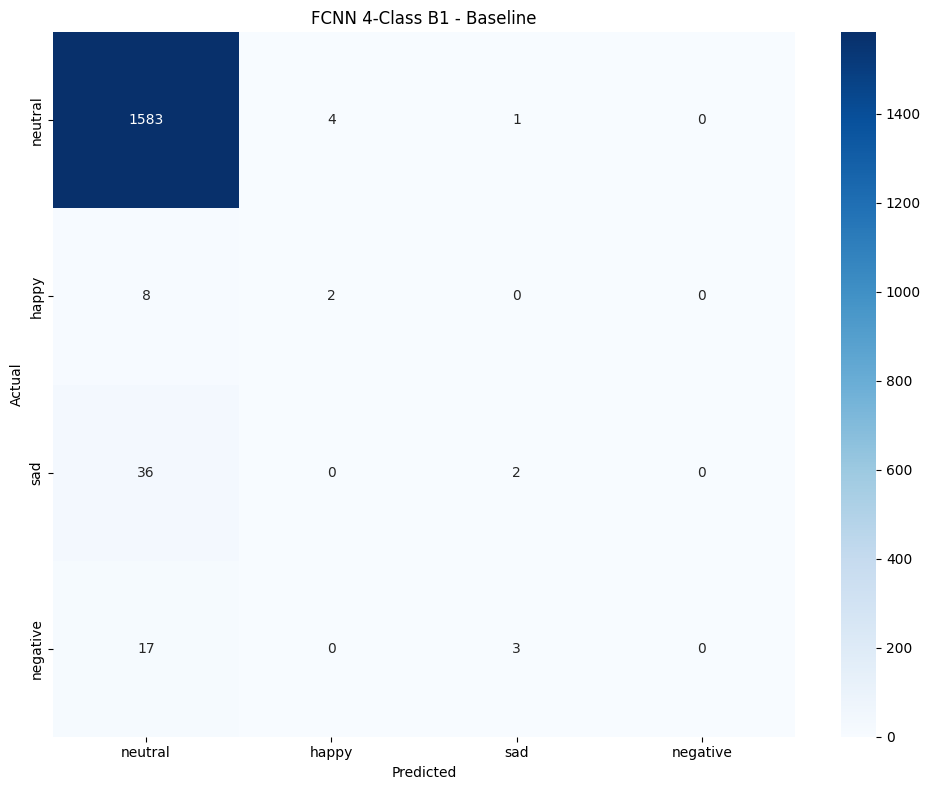

In [6]:
# Evaluate B1 on test set
print("=" * 60)
print("EVALUASI B1 - BASELINE")
print("=" * 60)
results_b1 = full_evaluation(model_b1, test_loader, criterion_b1, device, "fcnn", emotions=EMOTIONS)
plot_confusion_matrix(results_b1["confusion_matrix"], "FCNN 4-Class B1 - Baseline", emotions=EMOTIONS)

## 5. Skenario B2: Dengan Class Weights

In [7]:
# B2: With class weights (Cui et al., 2019)
weights = get_class_weights(DATASET_DIR, device)
print(f"Class weights: {weights}")

model_b2 = EmotionFCNN(input_dim=136, num_classes=NUM_CLASSES).to(device)
criterion_b2 = nn.CrossEntropyLoss(weight=weights)
optimizer_b2 = torch.optim.Adam(model_b2.parameters(), lr=LR)
scheduler_b2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_b2, mode="max", factor=0.5, patience=8, min_lr=1e-7
)

print("\nTraining B2 (class weights)...")
history_b2, best_epoch_b2 = train_model(
    model_b2, train_loader, val_loader, criterion_b2, optimizer_b2, scheduler_b2,
    device, model_type="fcnn", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "fcnn_4c_b2_weighted.pth")
)

Class weights: tensor([1.0000, 1.8865, 2.5717, 7.3799], device='cuda:0')

Training B2 (class weights)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.3409     0.4332     1.1707    0.9216   0.2398   0.000100  (0.7s)


     2      1.2152     0.6726     1.0692    0.8867   0.2350   0.000100  (0.7s)


     3      1.1393     0.7533     0.9593    0.9208   0.2582   0.000100  (0.7s)


     4      1.1062     0.7741     0.8770    0.9259   0.2887   0.000100  (0.6s)


...

    35      0.7903     0.7973     0.6794    0.9020   0.3994   0.000025  (0.7s)


    36      0.7787     0.8031     0.6703    0.8986   0.3887   0.000025  (0.7s)


    37      0.7903     0.8005     0.6559    0.9089   0.4112   0.000025  (0.6s)


    38      0.7773     0.8059     0.6744    0.9029   0.3934   0.000013  (0.6s)


    39      0.7858     0.7977     0.6683    0.9080   0.4245   0.000013  (0.6s)

Early stopping at epoch 39. Best epoch: 19 (val_f1=0.4258)

Best: epoch 19, val_acc=0.9106, val_f1=0.4258
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/4class/fcnn/fcnn_4c_b2_weighted.pth


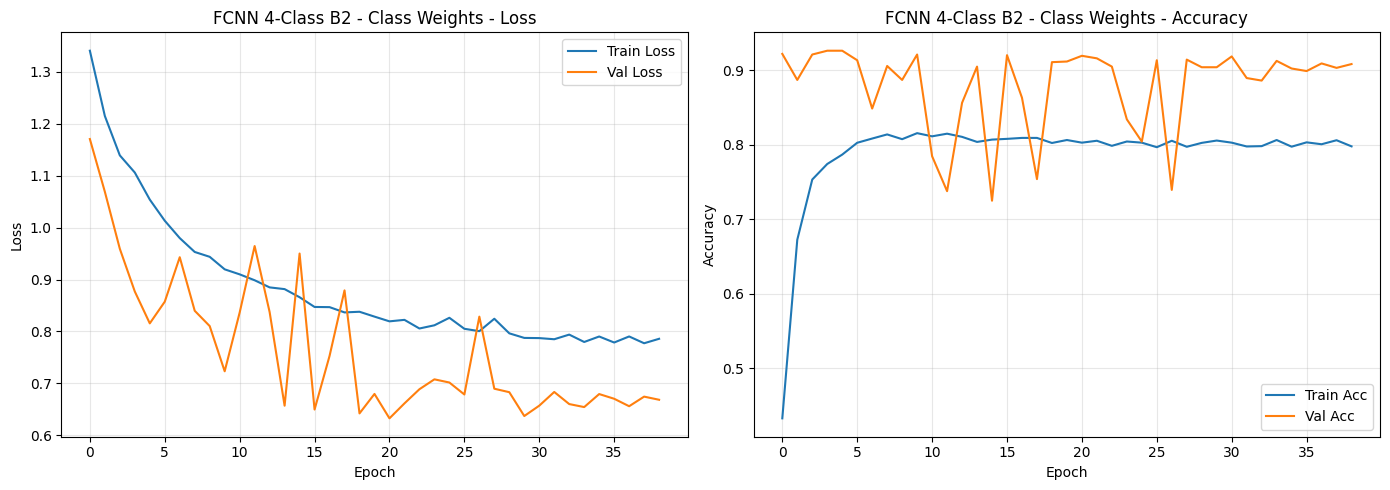

EVALUASI B2 - CLASS WEIGHTS


Test Loss: 0.4866
Test Accuracy: 0.9287
Test Macro F1: 0.3272
Test Weighted F1: 0.9288

Classification Report:
              precision    recall  f1-score   support

     neutral       0.97      0.96      0.96      1588
       happy       0.13      0.20      0.16        10
         sad       0.33      0.03      0.05        38
    negative       0.09      0.25      0.14        20

    accuracy                           0.93      1656
   macro avg       0.38      0.36      0.33      1656
weighted avg       0.94      0.93      0.93      1656



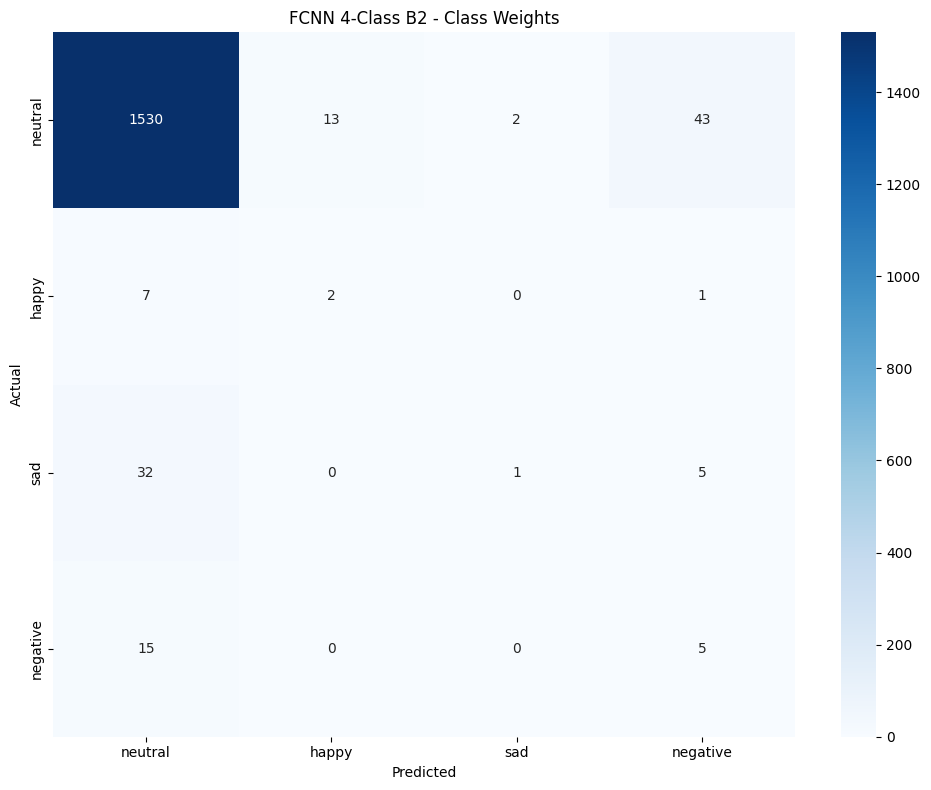

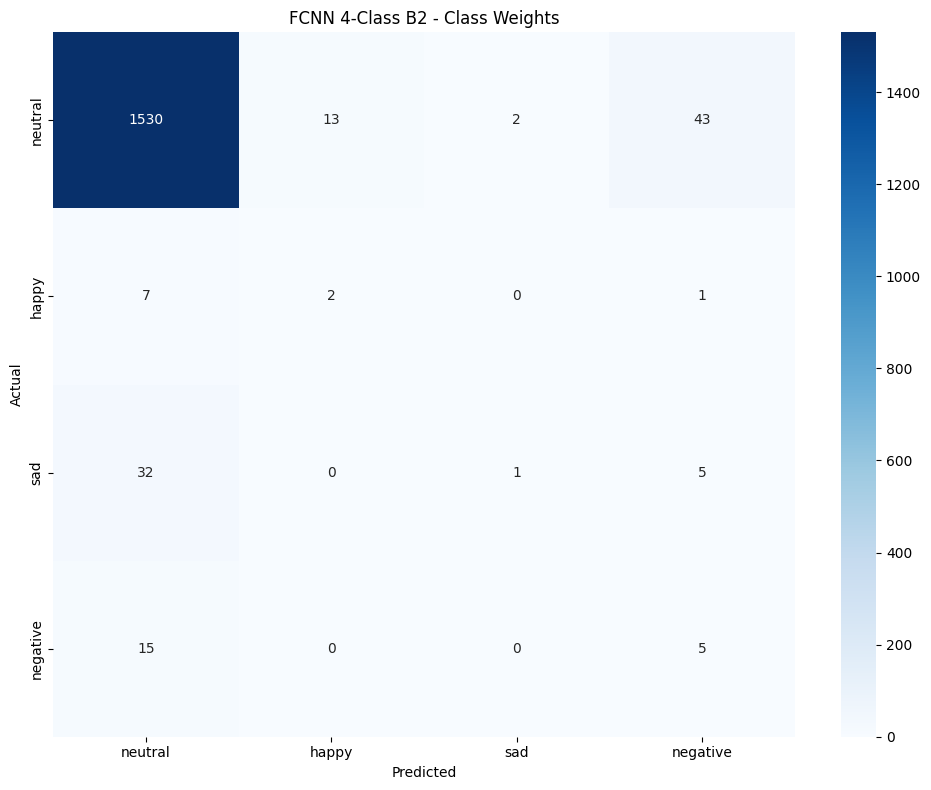

In [8]:
plot_training_history(history_b2, "FCNN 4-Class B2 - Class Weights")

print("=" * 60)
print("EVALUASI B2 - CLASS WEIGHTS")
print("=" * 60)
results_b2 = full_evaluation(model_b2, test_loader, criterion_b2, device, "fcnn", emotions=EMOTIONS)
plot_confusion_matrix(results_b2["confusion_matrix"], "FCNN 4-Class B2 - Class Weights", emotions=EMOTIONS)

## 6. Skenario B3: Class Weights + Augmentasi

In [9]:
# B3: Class weights + augmented data
train_loader_aug, _, _ = load_dataloaders(DATASET_AUG_DIR, BATCH_SIZE)
weights_aug = get_class_weights(DATASET_AUG_DIR, device)
print(f"Augmented class weights: {weights_aug}")

model_b3 = EmotionFCNN(input_dim=136, num_classes=NUM_CLASSES).to(device)
criterion_b3 = nn.CrossEntropyLoss(weight=weights_aug)
optimizer_b3 = torch.optim.Adam(model_b3.parameters(), lr=LR)
scheduler_b3 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_b3, mode="max", factor=0.5, patience=8, min_lr=1e-7
)

print("\nTraining B3 (class weights + augmentation)...")
history_b3, best_epoch_b3 = train_model(
    model_b3, train_loader_aug, val_loader, criterion_b3, optimizer_b3, scheduler_b3,
    device, model_type="fcnn", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "fcnn_4c_b3_augmented.pth")
)

Train: 7519 | Val: 1174 | Test: 1656
Train distribution:
     neutral: 5678
       happy: 751
         sad: 490
    negative: 600
Augmented class weights: tensor([1.0000, 1.8865, 2.5717, 2.2080], device='cuda:0')

Training B3 (class weights + augmentation)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.3927     0.2733     1.2189    0.4940   0.1941   0.000100  (0.6s)


     2      1.1636     0.5981     1.0373    0.8092   0.2341   0.000100  (0.6s)


     3      1.0582     0.7299     0.9250    0.8935   0.2553   0.000100  (0.7s)


     4      1.0049     0.7655     0.8580    0.9225   0.2399   0.000100  (0.6s)


...

    84      0.6062     0.8153     0.5250    0.9284   0.4707   0.000006  (0.7s)


    85      0.6186     0.8110     0.5320    0.9293   0.4719   0.000006  (0.7s)


    86      0.6139     0.8065     0.5332    0.9319   0.4769   0.000006  (0.7s)


    87      0.6190     0.8068     0.5318    0.9319   0.4769   0.000003  (0.6s)


    88      0.6099     0.8126     0.5335    0.9319   0.4769   0.000003  (0.7s)

Early stopping at epoch 88. Best epoch: 68 (val_f1=0.5057)

Best: epoch 68, val_acc=0.9319, val_f1=0.5057
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/4class/fcnn/fcnn_4c_b3_augmented.pth


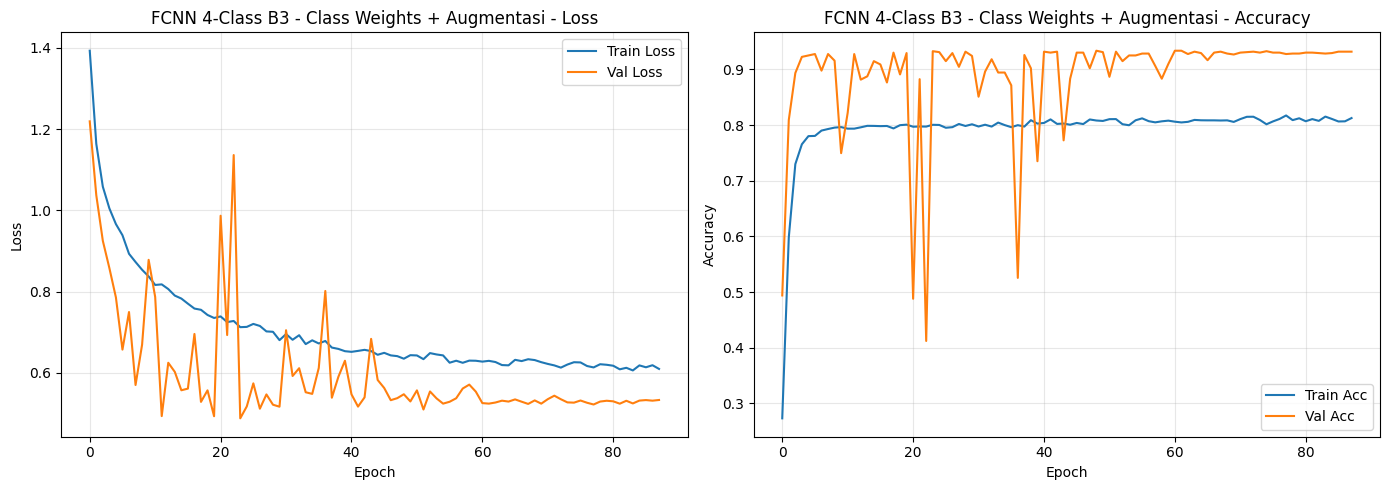

EVALUASI B3 - CLASS WEIGHTS + AUGMENTASI


Test Loss: 0.3248
Test Accuracy: 0.9438
Test Macro F1: 0.3941
Test Weighted F1: 0.9431

Classification Report:
              precision    recall  f1-score   support

     neutral       0.97      0.98      0.97      1588
       happy       0.11      0.30      0.16        10
         sad       0.77      0.26      0.39        38
    negative       0.06      0.05      0.05        20

    accuracy                           0.94      1656
   macro avg       0.48      0.40      0.39      1656
weighted avg       0.95      0.94      0.94      1656



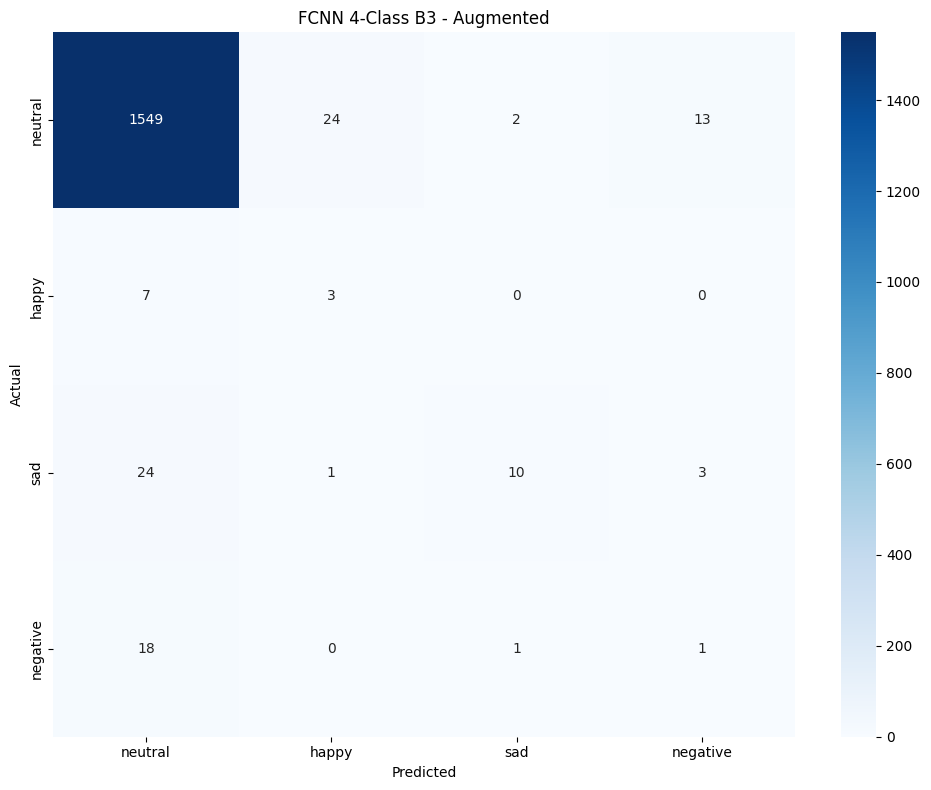

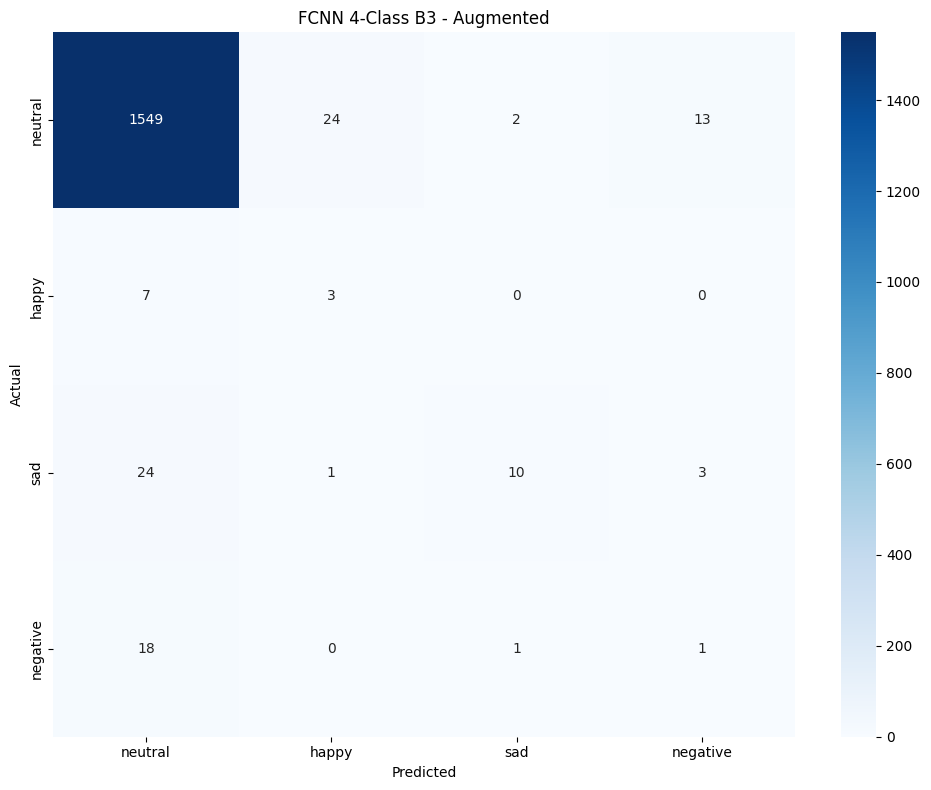

In [10]:
plot_training_history(history_b3, "FCNN 4-Class B3 - Class Weights + Augmentasi")

print("=" * 60)
print("EVALUASI B3 - CLASS WEIGHTS + AUGMENTASI")
print("=" * 60)
results_b3 = full_evaluation(model_b3, test_loader, criterion_b3, device, "fcnn", emotions=EMOTIONS)
plot_confusion_matrix(results_b3["confusion_matrix"], "FCNN 4-Class B3 - Augmented", emotions=EMOTIONS)

## 7. Perbandingan 3 Skenario

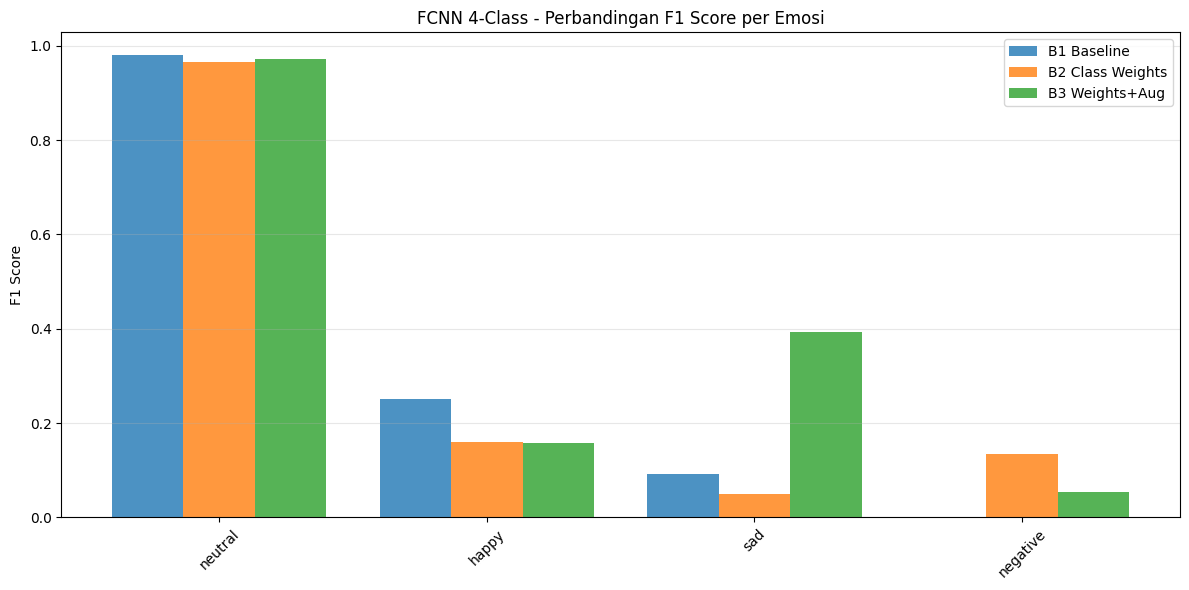

RINGKASAN FCNN 4-CLASS - 3 SKENARIO
Skenario                    Accuracy   Macro F1  Weighted F1
----------------------------------------------------------------------
B1 Baseline                   0.9583     0.3301       0.9430
B2 Class Weights              0.9287     0.3272       0.9288
B3 Weights+Aug                0.9438     0.3941       0.9431

Results saved to /home/bs000716/MOTHER-TANK/TRAIN/models/4class/fcnn/fcnn_4class_results.json


In [11]:
# Perbandingan per-class F1 score
all_results = {
    "B1 Baseline": results_b1,
    "B2 Class Weights": results_b2,
    "B3 Weights+Aug": results_b3,
}
plot_per_class_f1(all_results, "FCNN 4-Class - Perbandingan F1 Score per Emosi", emotions=EMOTIONS)

# Summary table
print("=" * 70)
print("RINGKASAN FCNN 4-CLASS - 3 SKENARIO")
print("=" * 70)
print(f"{'Skenario':<25} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("-" * 70)
for name, r in all_results.items():
    print(f"{name:<25} {r['test_accuracy']:>10.4f} {r['test_macro_f1']:>10.4f} {r['test_weighted_f1']:>12.4f}")

# Save results
fcnn_results = {}
for name, r in all_results.items():
    fcnn_results[name] = {
        "accuracy": float(r["test_accuracy"]),
        "macro_f1": float(r["test_macro_f1"]),
        "weighted_f1": float(r["test_weighted_f1"]),
    }
with open(OUTPUT_DIR / "fcnn_4class_results.json", "w") as f:
    json.dump(fcnn_results, f, indent=2)
print(f"\nResults saved to {OUTPUT_DIR / 'fcnn_4class_results.json'}")